# EXAM 2025R

In [627]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from jax import random
import seaborn as snb
from scipy.stats import beta as beta_dist
from scipy.stats import binom as binom_dist
from scipy.stats import betabinom as beta_binom_dist

### 2.1

In [628]:
x_star = jnp.array([0,1])

w_MAP = jnp.array([0.74077439, 0.74077439])

sigmoid = lambda x: 1. / (1 + jnp.exp(-x))

p = sigmoid(w_MAP.dot(x_star))

print(f'p(y^*|y, x^*=-3) = {p:3.2f} (using plug-in approximation)' )

p(y^*|y, x^*=-3) = 0.68 (using plug-in approximation)


### 2.2

In [629]:
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v)
log_ber = lambda y, p: y*jnp.log(p) + (1-y)*jnp.log(1-p)

In [630]:
y = jnp.array([0, 1])

lamb = 1/4

x = jnp.array([[0, 0], [1, 1]])

p2 = sigmoid(x@w_MAP)

log_prior = jnp.sum(log_npdf(w_MAP, 0, lamb**(-1)))
log_lik = jnp.sum(log_ber(y, p2))


log_lik + log_prior

Array(-4.2593102, dtype=float32)

### 2.3

In [631]:
lamb = 1/4
err = p2 - y
grad = -x.T@err -lamb*w_MAP
grad

Array([0., 0.], dtype=float32)

In [632]:
D = len(x)

v = p2*(1-p2)
H = -x.T @ jnp.diag(v) @ x -lamb*jnp.identity(D)
H

Array([[-0.40089694, -0.15089694],
       [-0.15089694, -0.40089694]], dtype=float32)

### 2.4

In [633]:
from scipy.stats import multivariate_normal as mvn

In [634]:
class LogisticRegression(object):

    def __init__(self, X, y, feature_transformation=lambda x: x, alpha=lamb):
        
        # store data and hyperparameters
        self.X0 = X
        self.y = y
        self.alpha = alpha
        self.feature_transformation = feature_transformation

        # apply feature transformation and standardize
        self.X = feature_transformation(self.X0)

        # store number of training data and number of features
        self.N, self.D = self.X.shape
        
        # get MAP by optimization
        self.w_MAP = w_MAP
        
    def predict(self, X, w):
        """ evaluates sigma(f(X)) """
        f = w@X.T
        return sigmoid(f)
    
    def log_joint(self, w):
        """
            evaluates log joint, i.e. log p(y, w), for each row in w.
            w is expected to be of shape [M, D], where D is the number of parameters in the model and M is the number of points to evaluated
        """
        p = self.predict(self.X, w)
        log_prior = jnp.sum(log_npdf(w, 0, 1./self.alpha), axis=1)
        log_lik = binom_dist.logpmf(self.y, p=p, n=1)
        log_joint = log_prior + log_lik.sum(axis=1)

        return log_joint
    
    def hessian(self, w):
        """ Returns hessian of log joint evaluated at w 
            Input:   w       (shape: [1, D])
            Returns: H       (shape: [D, D])            """
        
        ##############################################
        # Your solution goes here
        ##############################################
        
        p = self.predict(self.X, w)
        v = p*(1-p)
        H = -self.X.T @ jnp.diag(v) @ self.X -self.alpha*jnp.identity(self.D)
        
        ##############################################
        # End of solution
        ##############################################
        
        assert H.shape == (self.D, self.D), f"The shape of the Hessians appears to be wrong. Expected shape ({self.D}, {self.D}), but received {H.shape}. Check your implementation"
        return H

    def grad(self, w):
        """ Returns gradient of log joint evaluated at w 
            Input:   w          (shape: [1, D])
            Returns: grad       (shape: [1, D])            """
        
        ##############################################
        # Your solution goes here
        ##############################################
        
        p = self.predict(self.X, w)
        err = p - self.y
        grad = -jnp.sum(err.T*self.X, axis=0) -self.alpha*w
        grad = -x.T@err -lamb*w_MAP
        
        ##############################################
        # End of solution
        ##############################################

        #assert grad.shape == (1, self.D), f"The shape of the gradient appears to be wrong. Expected shape (1, {self.D}), but received {grad.shape}. Check your implementation"
        return grad

In [635]:
class LaplaceApproximation(object):

    def __init__(self, model):
        """ implements a laplace approximain q(w) = N(m, S), where m is the posterior mean and S is the posterior covariance """

        # store model
        self.model = model

        # implement Laplace approximation
        self.posterior_mean = model.w_MAP                               
        self.posterior_hessian = model.hessian(model.w_MAP)             
        self.posterior_cov = -jnp.linalg.inv(self.posterior_hessian)     

        # sanity check for dimensions
        assert self.posterior_mean.shape == (model.D,), f"The shape of the posterior mean appears wrong. Check your implementaion."
        assert self.posterior_hessian.shape == (model.D, model.D), f"The shape of the posterior Hessian appears wrong. Check your implementaion."
        assert self.posterior_cov.shape == (model.D, model.D), f"The shape of the posterior covariance appears wrong. Check your implementaion."

    def log_pdf(self, w):
        """ evaluate approximate posterior density at w """
        return mvn.logpdf(w, self.posterior_mean.ravel(), self.posterior_cov)
    
    def posterior_samples(self, key, num_samples):
        """ generate samples from posterior distribution """
        return random.multivariate_normal(key, self.posterior_mean, self.posterior_cov, shape=(num_samples, ))

In [636]:
model = LogisticRegression(x, y)
laplace = LaplaceApproximation(model)

key = random.PRNGKey(123)
w_samples = laplace.posterior_samples(key, 20000)
w_samples.mean(), w_samples.var()

(Array(0.7406703, dtype=float32), Array(2.89825, dtype=float32))

Normal(0.74, 2.9)

Finally, the probit approximation is given as:

In [637]:
from scipy.stats import norm as norm_dist

mu_f = 0.74
sigma2_f = 2.9

probit = lambda x: norm_dist.cdf(x)

probit(mu_f / (jnp.sqrt((8/jnp.pi) + sigma2_f)))

0.624409925933955

### 2.5

I would change from logistic regression to linear gaussian regression, with $\mathcal{N}(y \vert w^T x, \sigma^2)$ and have a joint $p(y, w) = \mathcal{N}(x w, \sigma^2) \mathcal{N}(m_0, S_0)$

## Part 3

### 3.1

0.75 * N(v, 1) + 0.25 * N(v, 3)

### 3.2

### 3.3

In [638]:
def ber(s, p):
    return (p**s)*(1-p)**(1-s)

ber(1, 1/4)

0.25

## Part 4

### 4.1

In [639]:
def generate_prior_samples(self, key, num_samples):
    """ generate samples from the prior  """
    return random.multivariate_normal(key, jnp.zeros(len(self.m)), (1/(1/2))*jnp.identity(len(self.m)), shape=(num_samples, ))


def generate_posterior_samples(self, key, num_samples):
    """ generate samples from the posterior  """
    return random.multivariate_normal(key, self.m.ravel(), self.S, shape=(num_samples, ))


m = jnp.array([-0.87, 2.13])
S = jnp.array([[0.41, 0.11], [0.11, 0.27]])

num_samples = 500000

prior_samples = random.multivariate_normal(key, jnp.zeros(len(m)), (1/(1/2))*jnp.identity(len(m)), shape=(num_samples, ))

prior_samples.shape

(500000, 2)

In [640]:
jnp.mean(prior_samples > 0, axis=0)

Array([0.499402, 0.500518], dtype=float32)

In [641]:
post_samples = random.multivariate_normal(key, m.ravel(), S, shape=(num_samples, ))

### 4.2

In [642]:
w2s = post_samples[:, 1]

theta_lower = jnp.quantile(w2s, 0.1, axis=0)
theta_upper = jnp.quantile(w2s, 1-0.1,)

theta_lower, theta_upper

(Array(1.462941, dtype=float32), Array(2.7970505, dtype=float32))

In [643]:
from scipy.stats import norm
lower, upper = norm.interval(confidence=0.8, loc=2.13, scale=jnp.sqrt(0.27))
print(f'p({lower:3.2f} < w_2 < {upper:3.2f}|y) ~ 0.8')

p(1.46 < w_2 < 2.80|y) ~ 0.8


### 4.3

In [644]:
jnp.mean(post_samples, axis=0)

Array([-0.8709609,  2.1302843], dtype=float32)

In [645]:
jnp.var(post_samples, axis=0)

Array([0.4097039 , 0.27054176], dtype=float32)

In [646]:
jnp.var(post_samples[:, 1] + post_samples[:, 0])

Array(0.9010074, dtype=float32)

In [647]:
x_star = 1

mu_f = -0.87028795 + x_star * 2.1308198
var_f = 0.9

mu_f, var_f

(1.2605318499999998, 0.9)

Another way:

In [648]:
m = jnp.array([-0.87, 2.13])
S = jnp.array([[0.41, 0.11], [0.11, 0.27]])
phi = jnp.array([1, 1])
print(f'p(f*|y) = N(f*|{phi@m:3.5f}, {phi.T@S@phi:3.5f})')

p(f*|y) = N(f*|1.26000, 0.90000)


### 4.4

Similar to posterior, but with added noise $\sigma^2$

$N(1.26, 0.9 + \sqrt{2})$

In [649]:
0.9 + jnp.sqrt(2)

Array(2.3142135, dtype=float32, weak_type=True)

So $N(1.26, 2.314)$

### 4.5

In [650]:
m1, m2, m3, m4 = -0.82, 2.37, -0.88, 0.37
v1, v2, v3, v4= 0.38, 0.19, 0.13, 0.09
H = 0.5 * jnp.log(2 * jnp.pi * jnp.e * v1) + 0.5 * jnp.log(2 * jnp.pi * jnp.e * v2) + 0.5 * jnp.log(2 * jnp.pi * jnp.e * v3) + 0.5 * jnp.log(2 * jnp.pi * jnp.e * v4)
print(f'Entropy of q: {H:3.2f}')

Entropy of q: 2.14


### 4.6

In [651]:
num_samples = 10**4

m = jnp.array([-0.82, 2.37, -0.88, 0.37])
v = jnp.array([0.38, 0.19, 0.13, 0.09])

w_samples = random.multivariate_normal(key, m, jnp.diag(v), shape=(num_samples, ))

In [652]:
x_star = 1
y_star = 1
npdf = lambda x, m, v: jnp.exp(-(x-m)**2/(2*v))/jnp.sqrt(2*jnp.pi*v)
q_samples = jnp.array([npdf(w_samples[:, 0], m1, v1), npdf(w_samples[:, 1], m2, v2), npdf(w_samples[:, 2], m3, v3), npdf(w_samples[:, 0], m4, v4)])


mu_samples = q_samples[:, 0] + q_samples[:, 1] * x_star
var_samples = jnp.exp(q_samples[:, 2] + q_samples[:, 3] * x_star)

post_samples = npdf(y_star, mu_samples, var_samples)

jnp.mean(post_samples)

Array(0.2543397, dtype=float32)

## Part 5

### 5.1

In [653]:
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v)

In [654]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        ##############################################
        # Your solution goes here
        ##############################################
        

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
        
        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))
        
        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)


        
        ##############################################
        # End of solution
        ##############################################
            
        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas

Acceptance ratio: 0.53


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


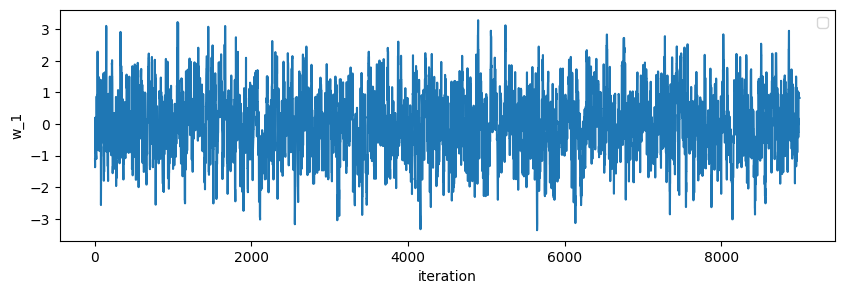

In [655]:
def log_post_dens(theta):
    w1, w2 = theta[0], theta[1]
    log_prior = log_npdf(w1, 0, 1) + log_npdf(w2, 0, 1)
    log_lik = log_npdf(2, w2 * jnp.tanh(w1 * 1), 2)
    return log_prior + log_lik

# specify number of parameters in the target distribution
num_params = 2
# specify the parameters of the MH algorithm
num_iterations = 10**4
warm_up = int(0.1*num_iterations)
tau = jnp.sqrt(1)

# run sampler
thetas = metropolis(log_post_dens, num_params, tau, num_iterations, theta_init=jnp.array([0, 0]), seed=0)
thetas_after_warmup = thetas[warm_up:, :]
x_line = jnp.linspace(1, len(thetas_after_warmup), len(thetas_after_warmup))
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(x_line, thetas_after_warmup[:, 0])
ax.set(xlabel='iteration', ylabel='w_1')
ax.legend();

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


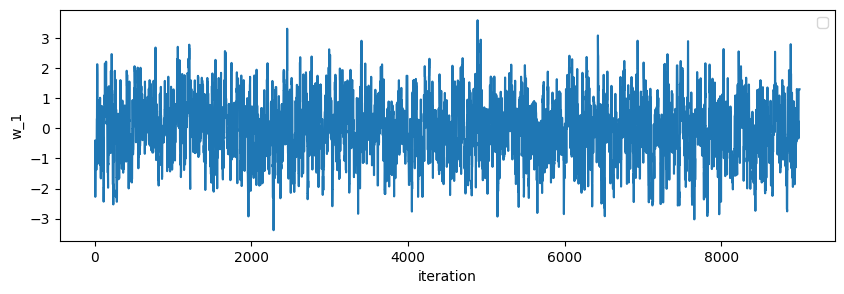

In [656]:
thetas_after_warmup = thetas[warm_up:, :]
x_line = jnp.linspace(1, len(thetas_after_warmup), len(thetas_after_warmup))
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(x_line, thetas_after_warmup[:, 1])
ax.set(xlabel='iteration', ylabel='w_1')
ax.legend();

### 5.2

In [657]:
w1s = thetas_after_warmup[:, 0]
w2s = thetas_after_warmup[:, 1]

x_star = jnp.array([2])

def f(x_star):
    return w2s * jnp.tanh(w1s * x_star)


jnp.mean(f(x_star) > 1)

Array(0.19920008, dtype=float32)

### 5.3

In [658]:
mu_f = jnp.mean(f(x_star))

S = len(w1s)

ys = f(x_star) + jnp.sqrt(2) * random.normal(key, shape=(S, ))

theta_lower = jnp.quantile(ys, 0.025, axis=0)
theta_upper = jnp.quantile(ys, 1-0.025, axis=0)

theta_lower, theta_upper

(Array(-2.730657, dtype=float32), Array(3.4919214, dtype=float32))

In [659]:
jnp.mean(ys)

Array(0.37927935, dtype=float32)